<a href="https://colab.research.google.com/github/Nawat1124/wind-turbine-scada-anomaly-detection/blob/main/03_eda_normal_operating_space.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 EDA: Normal Operating Space

## Purpose

This notebook analyses the normal operating space of CARE Wind Farm B after leakage-aware preprocessing.


It is not used to train the final anomaly detection model directly. Instead, it explains turbine-level heterogeneity, operating-state heterogeneity, feature redundancy, window-length rationale, KMeans-state thresholds, and PCA physical-family interpretation.


## Inputs

This notebook uses outputs from `02_data_preprocessing.ipynb`.


- `eda_base.parquet`
- `df_model.parquet`
- `model_ready_feature_list.json`
- `pca_explained_variance.csv`
- `pca_loadings.csv`

## Pipeline Flow

```text
Load preprocessing outputs
        |
        v
Define safe normal masks
        |
        v
Define physical feature families
        |
        v
Dataset overview
        |
        v
Gap diagnostics
        |
        v
Asset-level density analysis
        |
        v
IQR outlier diagnostics
        |
        v
Within and without family correlation analysis
        |
        v
Correlation heatmaps after pruning
        |
        v
ACF and Granger diagnostics
        |
        v
KMeans operating-state diagnostics
        |
        v
UMAP visualization
        |
        v
PCA explained variance and scatter plots
        |
        v
PCA physical-family interpretation
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path("/content/drive/MyDrive/windfarmB_reconstructed_observed_db_v3")

MODEL_READY_DIR = PROJECT_DIR / "model_ready_simple"
FIGURE_DIR = PROJECT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EDA_BASE_PATH = MODEL_READY_DIR / "eda_base.parquet"
DF_MODEL_PATH = MODEL_READY_DIR / "df_model.parquet"
FEATURE_LIST_PATH = MODEL_READY_DIR / "model_ready_feature_list.json"
PCA_EXPLAINED_PATH = MODEL_READY_DIR / "pca_explained_variance.csv"
PCA_LOADINGS_PATH = MODEL_READY_DIR / "pca_loadings.csv"

In [ ]:
eda = pd.read_parquet(EDA_BASE_PATH)
df_model = pd.read_parquet(DF_MODEL_PATH)

with open(FEATURE_LIST_PATH, "r") as f:
    MODEL_FEATURE_COLS = json.load(f)

pca_explained = pd.read_csv(PCA_EXPLAINED_PATH)
pca_loadings = pd.read_csv(PCA_LOADINGS_PATH, index_col=0)

TIME_COL = "reconstructed_time"

eda[TIME_COL] = pd.to_datetime(eda[TIME_COL])
df_model[TIME_COL] = pd.to_datetime(df_model[TIME_COL])

KMEANS_COLS = MODEL_FEATURE_COLS

print("eda:", eda.shape)
print("df_model:", df_model.shape)
print("n model features:", len(MODEL_FEATURE_COLS))

eda: (560060, 256)
df_model: (560060, 71)
n model features: 49


In [ ]:
normal_safe_mask = (
    eda["never_prediction_physical_row"].fillna(False)
    & eda["status_type_id"].isin([0, 2])
)

if "split_code" in eda.columns:
    train_normal_mask = normal_safe_mask & eda["split_code"].eq(0)
else:
    train_normal_mask = normal_safe_mask

print("normal safe rows:", int(normal_safe_mask.sum()))
print("train normal rows:", int(train_normal_mask.sum()))

AVG_FAMILY = {
    "power_energy_output": [
        "reactive_power_11_avg", "sensor_26_avg", "power_58_avg",
        "power_62_avg", "sensor_7_avg"
    ],
    "electrical_grid_current_voltage": [
        "sensor_13_avg", "sensor_14_avg", "sensor_15_avg",
        "sensor_16_avg", "sensor_17_avg", "sensor_18_avg",
        "sensor_23_avg", "sensor_24_avg", "sensor_27_avg",
        "sensor_28_avg", "sensor_29_avg", "sensor_30_avg"
    ],
    "wind_orientation_pitch_control": [
        "sensor_4_avg_sin", "sensor_4_avg_cos", "sensor_6_avg", "sensor_10_avg",
        "sensor_21_avg_sin", "sensor_21_avg_cos",
        "wind_speed_59_avg", "wind_speed_60_avg", "wind_speed_61_avg"
    ],
    "drivetrain_speed_torque": [
        "sensor_5_avg", "sensor_12_avg", "sensor_19_avg",
        "sensor_20_avg", "sensor_25_avg", "sensor_57_avg"
    ],
    "ambient_generator_motor_thermal": [
        "sensor_8_avg", "sensor_22_avg",
        "sensor_32_avg", "sensor_33_avg",
        "sensor_48_avg", "sensor_49_avg", "sensor_50_avg", "sensor_53_avg"
    ],
    "gearbox_bearing_oil_thermal": [
        "sensor_34_avg", "sensor_35_avg", "sensor_36_avg",
        "sensor_37_avg", "sensor_38_avg", "sensor_39_avg",
        "sensor_51_avg", "sensor_52_avg"
    ],
    "transformer_thermal": [
        "sensor_40_avg", "sensor_41_avg", "sensor_42_avg", "sensor_43_avg",
        "sensor_44_avg", "sensor_45_avg", "sensor_46_avg", "sensor_47_avg",
        "sensor_31_avg"
    ],
    "vibration_structural": [
        "sensor_9_avg", "sensor_54_avg", "sensor_55_avg", "sensor_56_avg"
    ],
}

DROP_REDUNDANT_AVG_COLS = [
    "sensor_16_avg",
    "sensor_17_avg",
    "sensor_18_avg",
    "sensor_13_avg",
    "sensor_14_avg",
    "sensor_15_avg",
    "sensor_19_avg",
    "sensor_20_avg",
    "sensor_26_avg",
    "sensor_57_avg",
    "wind_speed_59_avg",
    "sensor_6_avg",
]

AVG_FAMILY_PRUNED = {
    family: [c for c in cols if c not in DROP_REDUNDANT_AVG_COLS]
    for family, cols in AVG_FAMILY.items()
}

normal safe rows: 443248
train normal rows: 397198


这里还能再精简

In [ ]:
print("Rows:", len(eda))
print("Assets:", sorted(eda["asset_id"].dropna().unique()))

print("\nstatus_type_id counts:")
display(eda["status_type_id"].value_counts(dropna=False).sort_index())

print("\nnever_prediction_physical_row counts:")
display(eda["never_prediction_physical_row"].value_counts(dropna=False))

if "split_code" in eda.columns:
    print("\nsplit_code counts:")
    display(eda["split_code"].value_counts(dropna=False).sort_index())

print("\nModel features:")
display(pd.DataFrame({"feature": MODEL_FEATURE_COLS}))

Rows: 560060
Assets: [np.int64(0), np.int64(2), np.int64(5), np.int64(6), np.int64(7), np.int64(11), np.int64(12), np.int64(13), np.int64(14)]

status_type_id counts:


,count
status_type_id,
0,507393
1,29107
4,2614
5,20946



never_prediction_physical_row counts:


,count
never_prediction_physical_row,
True,490957
False,69103



split_code counts:


,count
split_code,
-1,116812
0,397198
1,44327
2,1723



Model features:


,feature
0,power_58_avg
1,power_62_avg
2,reactive_power_11_avg
3,sensor_10_avg
4,sensor_12_avg
5,sensor_21_avg_cos
6,sensor_21_avg_sin
7,sensor_22_avg
8,sensor_23_avg
9,sensor_24_avg


In [ ]:
STEP_MINUTES = 10
BIG_GAP_STEPS = 4

gap_rows = []

for aid, g in eda.groupby("asset_id", sort=True):
    g = g.sort_values("physical_order_index").reset_index(drop=True)

    dt = g[TIME_COL].diff()
    missing_steps = (dt / pd.Timedelta(minutes=STEP_MINUTES) - 1).fillna(0).astype(int)

    gap_idx = missing_steps[missing_steps > 0].index

    for i in gap_idx:
        n_miss = int(missing_steps.loc[i])

        gap_rows.append({
            "asset_id": aid,
            "prev_physical_order_index": int(g.loc[i - 1, "physical_order_index"]),
            "next_physical_order_index": int(g.loc[i, "physical_order_index"]),
            "gap_start_time": g.loc[i - 1, TIME_COL],
            "gap_end_time": g.loc[i, TIME_COL],
            "missing_steps": n_miss,
            "missing_minutes": n_miss * STEP_MINUTES,
            "gap_type": "small" if n_miss < BIG_GAP_STEPS else "big",
        })

gap_diag = pd.DataFrame(gap_rows)

if len(gap_diag) > 0:
    gap_diag = gap_diag.sort_values(["asset_id", "gap_start_time"]).reset_index(drop=True)

    gap_summary_by_asset = (
        gap_diag.groupby(["asset_id", "gap_type"])
        .agg(
            n_gaps=("gap_type", "size"),
            total_missing_steps=("missing_steps", "sum"),
            max_missing_steps=("missing_steps", "max"),
            median_missing_steps=("missing_steps", "median"),
        )
        .reset_index()
    )

    gap_summary_total = (
        gap_diag.groupby("gap_type")
        .agg(
            n_gaps=("gap_type", "size"),
            total_missing_steps=("missing_steps", "sum"),
            max_missing_steps=("missing_steps", "max"),
            median_missing_steps=("missing_steps", "median"),
        )
        .reset_index()
    )
else:
    gap_summary_by_asset = pd.DataFrame()
    gap_summary_total = pd.DataFrame()

print("gap_diag shape:", gap_diag.shape)
display(gap_diag.head(30))

print("gap summary by asset:")
display(gap_summary_by_asset)

print("gap summary total:")
display(gap_summary_total)

gap_diag shape: (74, 8)


,asset_id,prev_physical_order_index,next_physical_order_index,gap_start_time,gap_end_time,missing_steps,missing_minutes,gap_type
0,0,1959,1960,2019-10-07 10:40:00,2019-10-07 11:00:00,1,10,small
1,0,3804,3805,2019-10-20 06:20:00,2019-10-20 10:10:00,22,220,big
2,0,3806,3807,2019-10-20 10:20:00,2019-10-20 10:40:00,1,10,small
3,0,3807,3808,2019-10-20 10:40:00,2019-10-20 15:00:00,25,250,big
4,0,4050,4051,2019-10-22 07:20:00,2019-10-22 13:00:00,33,330,big
5,0,4157,4158,2019-10-23 06:40:00,2019-10-23 14:50:00,48,480,big
6,0,4167,4168,2019-10-23 16:20:00,2019-10-23 17:10:00,4,40,big
7,0,4169,4170,2019-10-23 17:20:00,2019-10-23 20:30:00,18,180,big
8,0,4170,4171,2019-10-23 20:30:00,2019-10-23 20:50:00,1,10,small
9,0,4174,4175,2019-10-23 21:20:00,2019-10-24 03:30:00,36,360,big


gap summary by asset:


,asset_id,gap_type,n_gaps,total_missing_steps,max_missing_steps,median_missing_steps
0,0,big,12,328,48,29.0
1,0,small,10,15,3,1.0
2,2,big,7,503,310,17.0
3,2,small,17,26,3,1.0
4,5,small,12,17,2,1.0
5,6,small,2,2,1,1.0
6,7,big,1,228,228,228.0
7,7,small,1,1,1,1.0
8,11,big,2,28,14,14.0
9,11,small,3,3,1,1.0


gap summary total:


,gap_type,n_gaps,total_missing_steps,max_missing_steps,median_missing_steps
0,big,24,1112,310,20.0
1,small,50,70,3,1.0


Available density columns: ['sensor_47_avg', 'sensor_40_avg', 'sensor_38_avg', 'sensor_51_avg']
Missing density columns: []


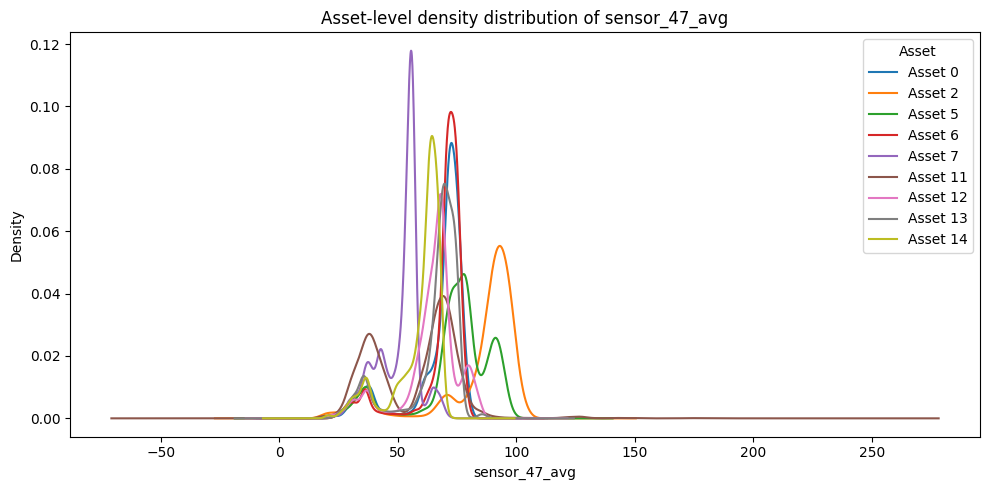

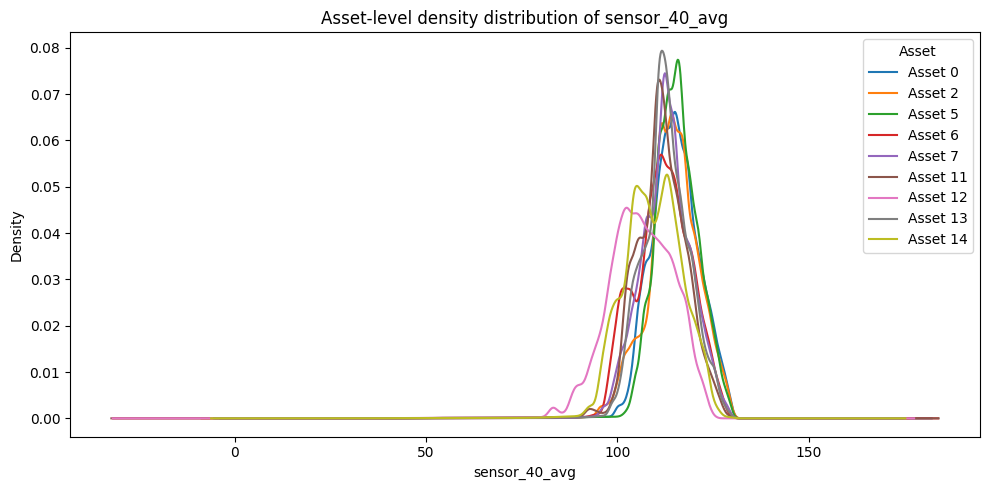

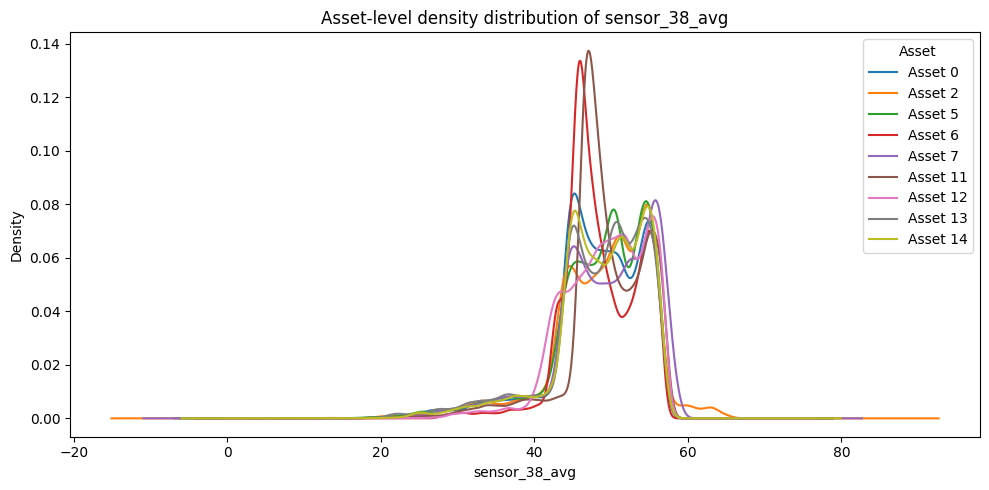

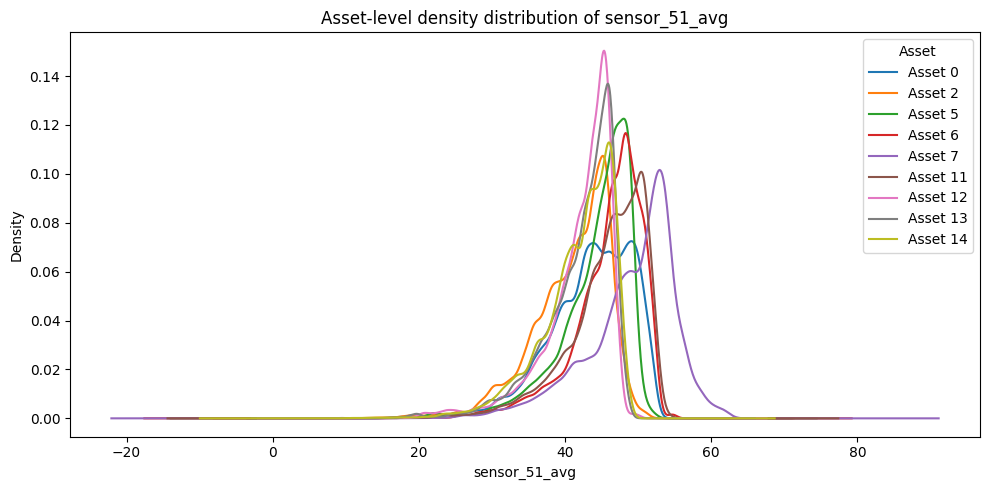

In [ ]:
COLS_TO_PLOT = [
    "sensor_47_avg",
    "sensor_40_avg",
    "sensor_38_avg",
    "sensor_51_avg",
]

available_cols = [c for c in COLS_TO_PLOT if c in eda.columns]
missing_cols = [c for c in COLS_TO_PLOT if c not in eda.columns]

print("Available density columns:", available_cols)
print("Missing density columns:", missing_cols)

d_plot = eda.loc[
    normal_safe_mask,
    ["asset_id"] + available_cols
].copy()

for col in available_cols:
    plt.figure(figsize=(10, 5))

    for aid, g in d_plot.groupby("asset_id"):
        x = g[col].dropna()

        if len(x) < 50:
            continue

        x.plot(
            kind="density",
            linewidth=1.5,
            label=f"Asset {aid}"
        )

    plt.title(f"Asset-level density distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend(title="Asset")
    plt.tight_layout()
    plt.show()

In [ ]:
FEATURE_PREFIXES = ("sensor_", "power_", "reactive_")

iqr_feature_cols = [
    c for c in eda.columns
    if c.startswith(FEATURE_PREFIXES)
    and pd.api.types.is_numeric_dtype(eda[c])
    and not c.endswith(("_sin", "_cos"))
    and "__" not in c
]

print("IQR fitting rows:", int(normal_safe_mask.sum()))
print("n IQR feature cols:", len(iqr_feature_cols))

K_IQR = 3.0
MIN_N_ASSET = 100

threshold_records = []

for col in iqr_feature_cols:
    for aid, g in eda.loc[normal_safe_mask, ["asset_id", col]].groupby("asset_id"):
        x = g[col].dropna()
        n = len(x)

        if n < MIN_N_ASSET:
            lower = np.nan
            upper = np.nan
        else:
            q1 = x.quantile(0.25)
            q3 = x.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - K_IQR * iqr
            upper = q3 + K_IQR * iqr

        threshold_records.append({
            "asset_id": aid,
            "feature": col,
            "lower": lower,
            "upper": upper,
            "n_fit": n,
        })

iqr_thresholds = pd.DataFrame(threshold_records)

flag_data = {}
asset_id = eda["asset_id"]

for col in iqr_feature_cols:
    sub = iqr_thresholds[iqr_thresholds["feature"].eq(col)]

    lower_map = sub.set_index("asset_id")["lower"].to_dict()
    upper_map = sub.set_index("asset_id")["upper"].to_dict()

    lower = asset_id.map(lower_map)
    upper = asset_id.map(upper_map)

    x = eda[col]

    flag_data[col + "__iqr_outlier"] = (
        x.notna()
        & lower.notna()
        & upper.notna()
        & ((x < lower) | (x > upper))
    ).to_numpy(dtype=bool)

outlier_flags = pd.DataFrame(flag_data, index=eda.index)

eda_iqr = pd.concat(
    [
        eda,
        outlier_flags,
        pd.DataFrame({
            "row_iqr_outlier_n": outlier_flags.sum(axis=1),
            "row_iqr_outlier_any": outlier_flags.any(axis=1),
        }, index=eda.index)
    ],
    axis=1
)

iqr_outlier_summary = pd.DataFrame({
    "feature": [c.replace("__iqr_outlier", "") for c in outlier_flags.columns],
    "n_outlier": outlier_flags.sum(axis=0).to_numpy(dtype=int),
    "outlier_ratio": outlier_flags.mean(axis=0).to_numpy(dtype=float),
})

iqr_outlier_summary = (
    iqr_outlier_summary
    .sort_values("outlier_ratio", ascending=False)
    .reset_index(drop=True)
)

print("IQR flagging done. No clipping was applied.")
print("Rows with any IQR outlier:")
display(eda_iqr["row_iqr_outlier_any"].value_counts(dropna=False))

display(iqr_outlier_summary.head(40))

IQR fitting rows: 443248
n IQR feature cols: 214
IQR flagging done. No clipping was applied.
Rows with any IQR outlier:


,count
row_iqr_outlier_any,
True,322496
False,237564


,feature,n_outlier,outlier_ratio
0,sensor_39_max,107230,0.191462
1,sensor_35_avg,105947,0.189171
2,sensor_35_max,102373,0.182789
3,sensor_34_std,102118,0.182334
4,sensor_36_max,101473,0.181182
5,sensor_34_avg,101400,0.181052
6,sensor_35_std,98862,0.176520
7,sensor_43_min,97428,0.173960
8,sensor_39_avg,95466,0.170457
9,sensor_34_max,94361,0.168484


plot rows: 443248
plot columns: ['sensor_35_avg', 'sensor_34_avg', 'sensor_39_avg', 'sensor_36_avg', 'sensor_37_avg', 'sensor_47_avg', 'sensor_10_avg', 'sensor_32_avg', 'sensor_9_avg']


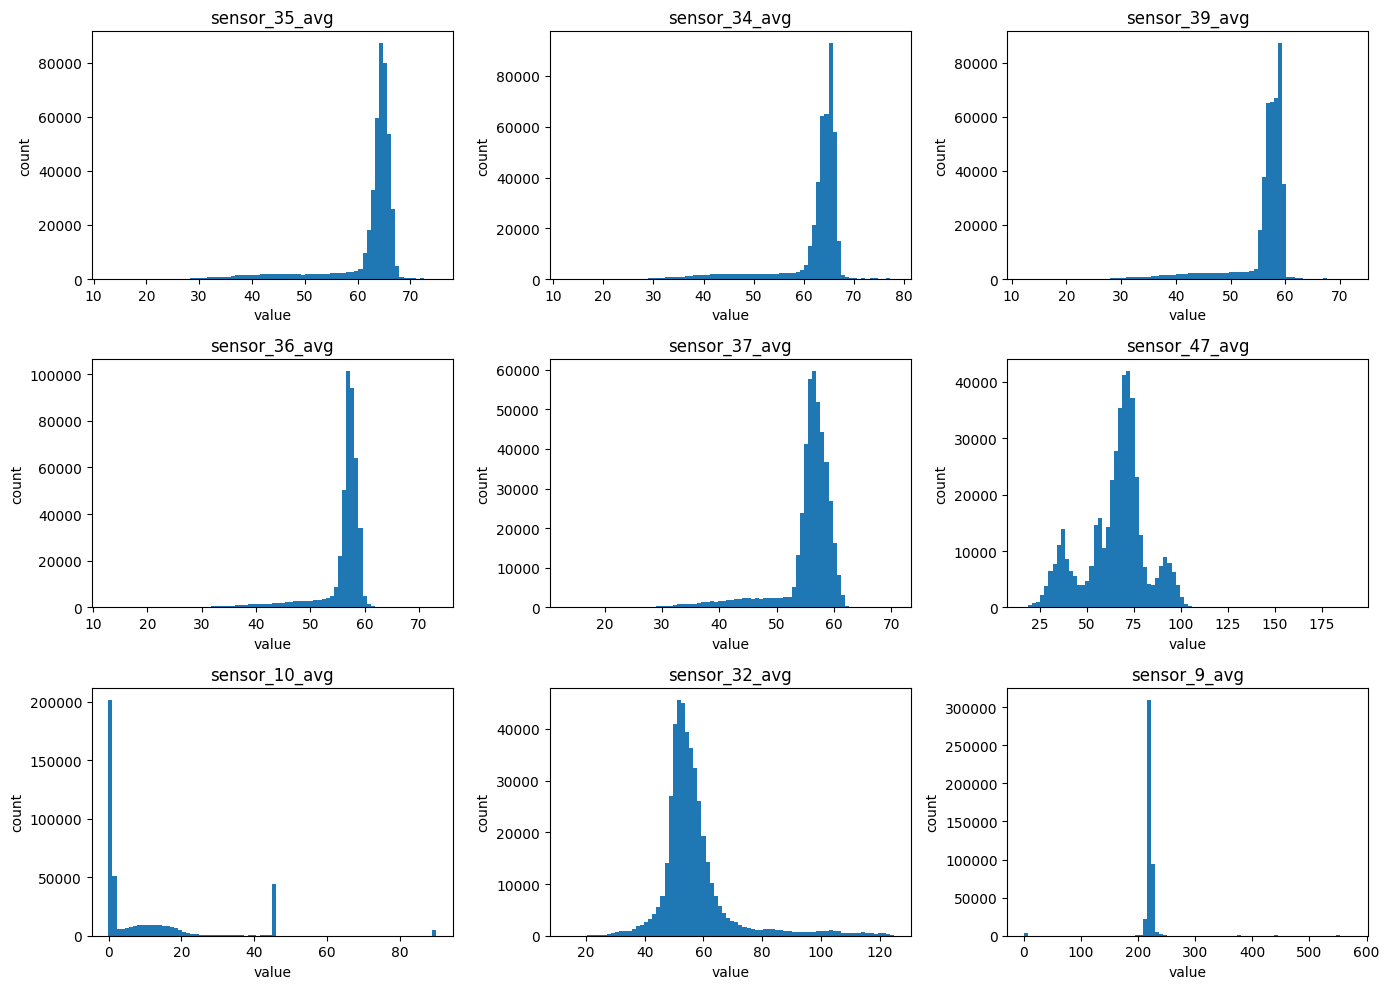

In [ ]:
cols_to_plot = [
    "sensor_35_avg",
    "sensor_34_avg",
    "sensor_39_avg",
    "sensor_36_avg",
    "sensor_37_avg",
    "sensor_47_avg",
    "sensor_10_avg",
    "sensor_32_avg",
    "sensor_9_avg",
]

cols_to_plot = [c for c in cols_to_plot if c in eda.columns]

d_plot = eda.loc[normal_safe_mask, cols_to_plot]

print("plot rows:", len(d_plot))
print("plot columns:", cols_to_plot)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for ax, col in zip(axes, cols_to_plot):
    x = d_plot[col].dropna()

    ax.hist(x, bins=80)
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

for ax in axes[len(cols_to_plot):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from itertools import combinations

CORR_METHOD = "pearson"
HIGH_CORR_THRESHOLD = 0.95

pair_records = []
corr_by_family = {}

for family, cols in AVG_FAMILY.items():
    cols = [c for c in cols if c in eda.columns]

    if len(cols) < 2:
        continue

    x = eda.loc[normal_safe_mask, cols].copy()
    corr = x.corr(method=CORR_METHOD)

    corr_by_family[family] = corr

    for f1, f2 in combinations(cols, 2):
        value = corr.loc[f1, f2]

        pair_records.append({
            "family": family,
            "feature_1": f1,
            "feature_2": f2,
            "corr": value,
            "abs_corr": abs(value),
        })

within_family_corr_pairs = (
    pd.DataFrame(pair_records)
    .sort_values(["abs_corr", "family"], ascending=[False, True])
    .reset_index(drop=True)
)

high_corr_pairs = (
    within_family_corr_pairs[
        within_family_corr_pairs["abs_corr"] >= HIGH_CORR_THRESHOLD
    ]
    .reset_index(drop=True)
)

family_corr_summary = (
    within_family_corr_pairs
    .groupby("family")
    .agg(
        n_pairs=("abs_corr", "size"),
        mean_abs_corr=("abs_corr", "mean"),
        median_abs_corr=("abs_corr", "median"),
        max_abs_corr=("abs_corr", "max"),
        n_high_corr=("abs_corr", lambda s: int((s >= HIGH_CORR_THRESHOLD).sum())),
    )
    .sort_values("max_abs_corr", ascending=False)
    .reset_index()
)

print("All within-family correlation pairs:")
display(within_family_corr_pairs.head(50))

print(f"High within-family correlation pairs: abs_corr >= {HIGH_CORR_THRESHOLD}")
display(high_corr_pairs)

print("Family correlation summary:")
display(family_corr_summary)

All within-family correlation pairs:


,family,feature_1,feature_2,corr,abs_corr
0,electrical_grid_current_voltage,sensor_18_avg,sensor_27_avg,0.999997,0.999997
1,drivetrain_speed_torque,sensor_19_avg,sensor_20_avg,0.999997,0.999997
2,electrical_grid_current_voltage,sensor_17_avg,sensor_27_avg,0.999996,0.999996
3,electrical_grid_current_voltage,sensor_16_avg,sensor_27_avg,0.999996,0.999996
4,electrical_grid_current_voltage,sensor_17_avg,sensor_18_avg,0.999991,0.999991
5,electrical_grid_current_voltage,sensor_16_avg,sensor_18_avg,0.999991,0.999991
6,electrical_grid_current_voltage,sensor_16_avg,sensor_17_avg,0.999988,0.999988
7,drivetrain_speed_torque,sensor_20_avg,sensor_25_avg,0.999949,0.999949
8,drivetrain_speed_torque,sensor_19_avg,sensor_25_avg,0.999949,0.999949
9,power_energy_output,sensor_26_avg,power_62_avg,0.999668,0.999668


High within-family correlation pairs: abs_corr >= 0.95


,family,feature_1,feature_2,corr,abs_corr
0,electrical_grid_current_voltage,sensor_18_avg,sensor_27_avg,0.999997,0.999997
1,drivetrain_speed_torque,sensor_19_avg,sensor_20_avg,0.999997,0.999997
2,electrical_grid_current_voltage,sensor_17_avg,sensor_27_avg,0.999996,0.999996
3,electrical_grid_current_voltage,sensor_16_avg,sensor_27_avg,0.999996,0.999996
4,electrical_grid_current_voltage,sensor_17_avg,sensor_18_avg,0.999991,0.999991
5,electrical_grid_current_voltage,sensor_16_avg,sensor_18_avg,0.999991,0.999991
6,electrical_grid_current_voltage,sensor_16_avg,sensor_17_avg,0.999988,0.999988
7,drivetrain_speed_torque,sensor_20_avg,sensor_25_avg,0.999949,0.999949
8,drivetrain_speed_torque,sensor_19_avg,sensor_25_avg,0.999949,0.999949
9,power_energy_output,sensor_26_avg,power_62_avg,0.999668,0.999668


Family correlation summary:


,family,n_pairs,mean_abs_corr,median_abs_corr,max_abs_corr,n_high_corr
0,electrical_grid_current_voltage,66,0.795115,0.861874,0.999997,15
1,drivetrain_speed_torque,15,0.595864,0.810879,0.999997,4
2,power_energy_output,10,0.806886,0.827617,0.999668,1
3,wind_orientation_pitch_control,36,0.311544,0.184133,0.998624,4
4,transformer_thermal,36,0.592739,0.553341,0.993836,4
5,gearbox_bearing_oil_thermal,28,0.646327,0.670670,0.991695,6
6,ambient_generator_motor_thermal,28,0.503284,0.652202,0.982073,1
7,vibration_structural,6,0.250252,0.202781,0.650764,0


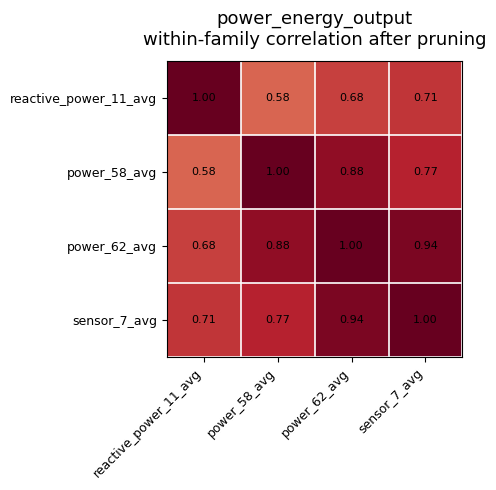

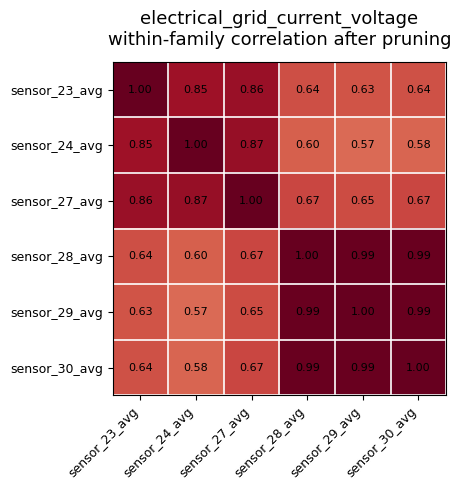

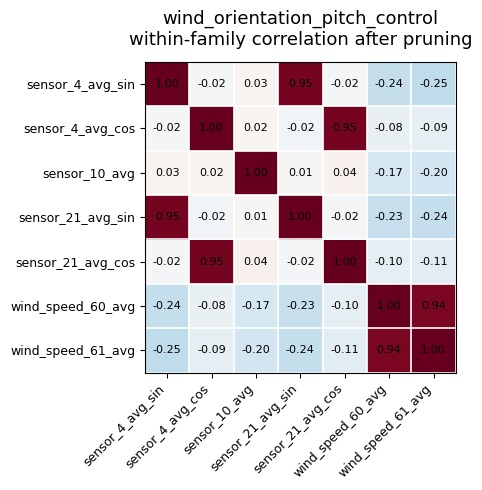

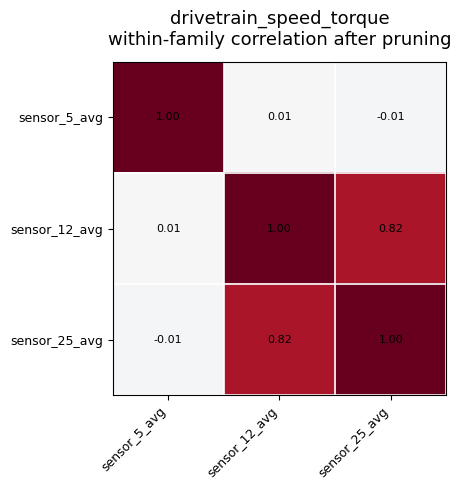

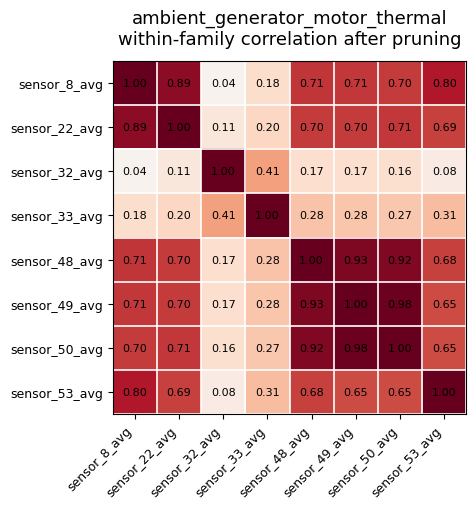

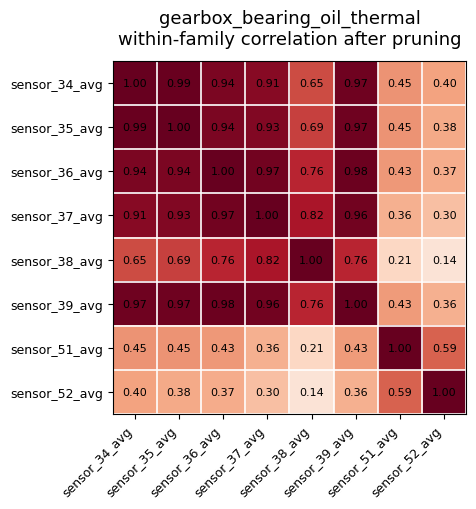

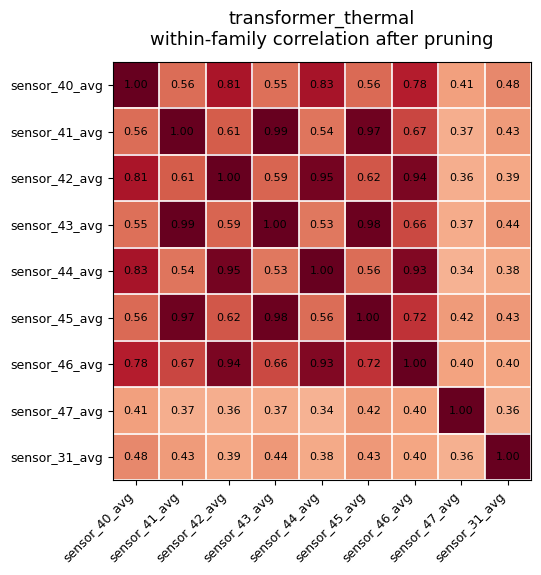

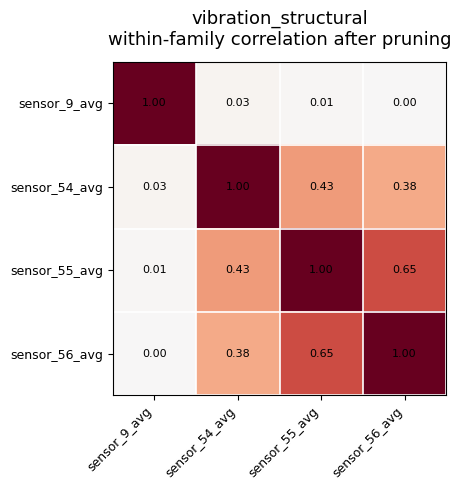

In [ ]:
for family, cols in AVG_FAMILY_PRUNED.items():
    cols = [c for c in cols if c in eda.columns]

    if len(cols) < 2:
        print(f"skip {family}: less than 2 features")
        continue

    corr = eda.loc[normal_safe_mask, cols].corr(method="pearson")
    n = len(cols)

    fig, ax = plt.subplots(figsize=(max(6, n * 0.75), max(5, n * 0.65)))

    im = ax.imshow(
        corr,
        cmap="RdBu_r",
        vmin=-1,
        vmax=1,
        aspect="equal"
    )

    ax.set_title(f"{family}\nwithin-family correlation after pruning", fontsize=13, pad=12)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(cols, fontsize=9)

    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)

    for i in range(n):
        for j in range(n):
            value = corr.iloc[i, j]
            text = "" if pd.isna(value) else f"{value:.2f}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8,
                color="black"
            )

    plt.tight_layout()
    plt.show()

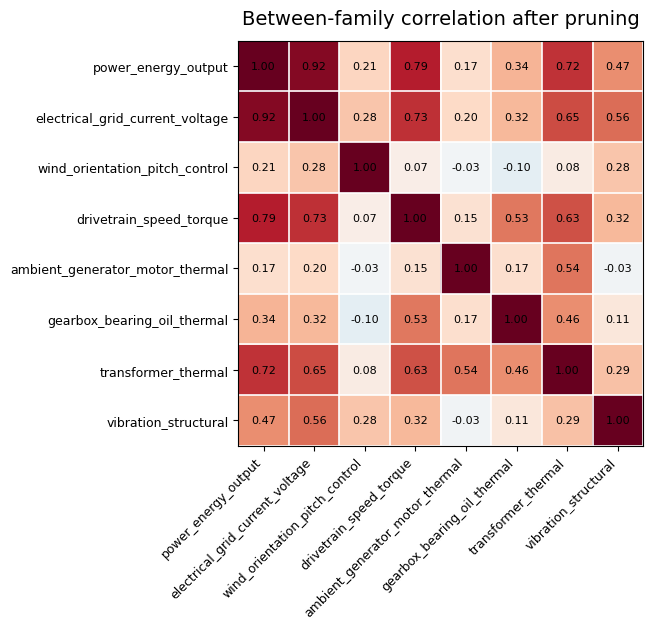

In [ ]:
family_signal = {}

for family, cols in AVG_FAMILY_PRUNED.items():
    cols = [c for c in cols if c in eda.columns]

    if len(cols) == 0:
        continue

    x = eda.loc[normal_safe_mask, cols].copy()
    x = (x - x.mean()) / x.std(ddof=0)

    family_signal[family] = x.mean(axis=1)

family_df = pd.DataFrame(family_signal)
family_corr = family_df.corr(method="pearson")

families = family_corr.columns.tolist()
n = len(families)

fig, ax = plt.subplots(figsize=(max(7, n * 0.9), max(6, n * 0.8)))

im = ax.imshow(
    family_corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    aspect="equal"
)

ax.set_title("Between-family correlation after pruning", fontsize=14, pad=12)

ax.set_xticks(np.arange(n))
ax.set_yticks(np.arange(n))

ax.set_xticklabels(families, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(families, fontsize=9)

ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

for i in range(n):
    for j in range(n):
        value = family_corr.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

plt.tight_layout()
plt.show()

ACF rows: 45740
Max lag: 50 steps = 500 minutes


<Figure size 1000x400 with 0 Axes>

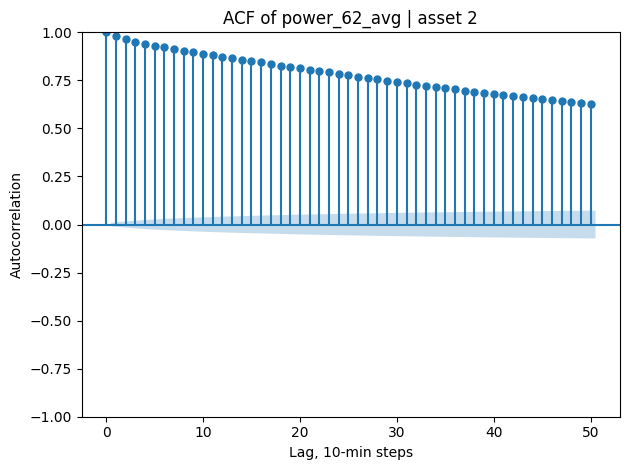

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

ASSET_ID = 2
TARGET = "power_62_avg"
MAX_LAG = 50

ORDER_COL = "physical_order_index"

mask = normal_safe_mask & eda["asset_id"].eq(ASSET_ID)

x = (
    eda.loc[mask, [ORDER_COL, TIME_COL, TARGET]]
    .sort_values(ORDER_COL)[TARGET]
    .dropna()
)

print("ACF rows:", len(x))
print("Max lag:", MAX_LAG, "steps =", MAX_LAG * 10, "minutes")

plt.figure(figsize=(10, 4))
plot_acf(x, lags=MAX_LAG, alpha=0.05)
plt.title(f"ACF of {TARGET} | asset {ASSET_ID}")
plt.xlabel("Lag, 10-min steps")
plt.ylabel("Autocorrelation")
plt.tight_layout()
plt.show()

Rows used: 45740
Features used: ['wind_speed_59_avg', 'sensor_16_avg', 'sensor_12_avg', 'sensor_34_avg', 'sensor_40_avg', 'sensor_54_avg']


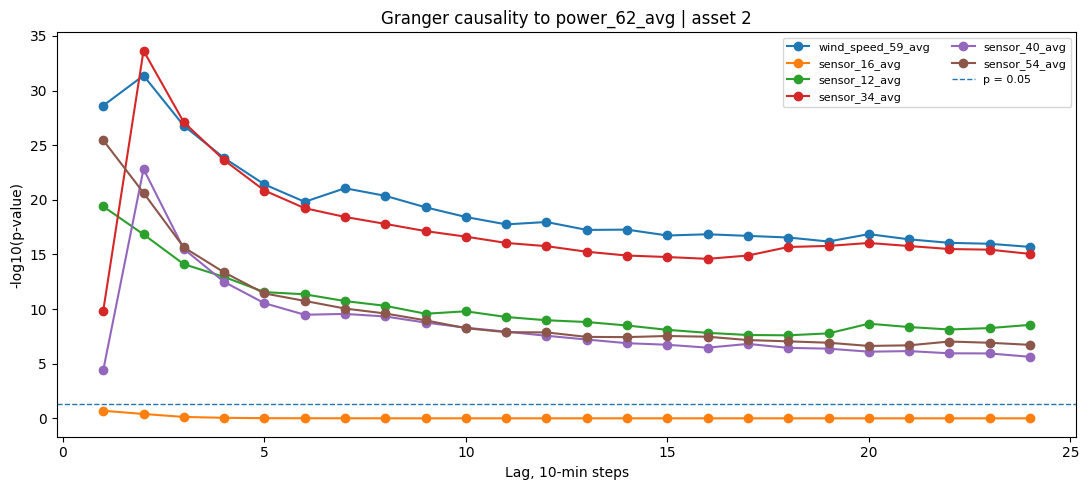

,feature,best_lag_step,best_lag_minutes,best_pvalue
0,sensor_34_avg,2,20,2.265829e-34
1,wind_speed_59_avg,2,20,4.261153e-32
2,sensor_54_avg,1,10,3.523620e-26
3,sensor_40_avg,2,20,1.520029e-23
4,sensor_12_avg,1,10,4.068526e-20
5,sensor_16_avg,1,10,2.022325e-01


In [ ]:
import warnings
from statsmodels.tsa.stattools import grangercausalitytests

ASSET_ID = 2
TARGET = "power_62_avg"
MAX_LAG = 24

CANDIDATE_COLS = [
    "wind_speed_59_avg",
    "sensor_16_avg",
    "sensor_12_avg",
    "sensor_34_avg",
    "sensor_40_avg",
    "sensor_54_avg",
]

ORDER_COL = "physical_order_index"

mask = normal_safe_mask & eda["asset_id"].eq(ASSET_ID)

use_cols = [TARGET] + [c for c in CANDIDATE_COLS if c in eda.columns]

g = (
    eda.loc[mask, [ORDER_COL] + use_cols]
    .sort_values(ORDER_COL)
    .dropna()
)

print("Rows used:", len(g))
print("Features used:", [c for c in use_cols if c != TARGET])

plt.figure(figsize=(11, 5))

summary = []

for col in use_cols:
    if col == TARGET:
        continue

    tmp = g[[TARGET, col]].dropna()

    if len(tmp) < MAX_LAG * 5:
        print("Skip, too few rows:", col)
        continue

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = grangercausalitytests(
            tmp[[TARGET, col]],
            maxlag=MAX_LAG,
            verbose=False
        )

    lags = np.arange(1, MAX_LAG + 1)

    pvals = np.array([
        res[lag][0]["ssr_ftest"][1]
        for lag in lags
    ])

    y = -np.log10(np.maximum(pvals, 1e-300))

    plt.plot(lags, y, marker="o", linewidth=1.5, label=col)

    best_i = np.argmin(pvals)
    summary.append({
        "feature": col,
        "best_lag_step": int(lags[best_i]),
        "best_lag_minutes": int(lags[best_i] * 10),
        "best_pvalue": float(pvals[best_i]),
    })

plt.axhline(-np.log10(0.05), linestyle="--", linewidth=1, label="p = 0.05")

plt.title(f"Granger causality to {TARGET} | asset {ASSET_ID}")
plt.xlabel("Lag, 10-min steps")
plt.ylabel("-log10(p-value)")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

granger_summary = (
    pd.DataFrame(summary)
    .sort_values("best_pvalue")
    .reset_index(drop=True)
)

display(granger_summary)

In [ ]:
pos = np.flatnonzero(train_normal_mask.to_numpy())

kmeans_summary = (
    eda.loc[pos, ["kmeans_state", "kmeans_center_dist"]]
    .groupby("kmeans_state")
    .agg(
        n=("kmeans_state", "size"),
        dist_median=("kmeans_center_dist", "median"),
        dist_q95=("kmeans_center_dist", lambda x: x.quantile(0.95)),
        dist_q99=("kmeans_center_dist", lambda x: x.quantile(0.99)),
        dist_mean=("kmeans_center_dist", "mean"),
        dist_max=("kmeans_center_dist", "max")
    )
    .reset_index()
)

kmeans_summary["ratio"] = kmeans_summary["n"] / kmeans_summary["n"].sum()
kmeans_summary = kmeans_summary.sort_values("n", ascending=False)

print("Occupied states:", kmeans_summary["kmeans_state"].nunique())
print("Total assigned rows:", kmeans_summary["n"].sum())

display(kmeans_summary)

p = kmeans_summary["ratio"].to_numpy()
effective_n_states = np.exp(-(p * np.log(p)).sum())

print("Effective number of KMeans states:", effective_n_states)

Occupied states: 6
Total assigned rows: 397198


,kmeans_state,n,dist_median,dist_q95,dist_q99,dist_mean,dist_max,ratio
2,2,91236,3.826469,6.415927,8.966841,4.183443,16.981333,0.229699
0,0,74510,3.929430,6.363350,8.922281,4.217263,19.169147,0.187589
4,4,72438,4.485475,6.739961,9.713152,4.707455,31.072981,0.182373
1,1,64904,4.398672,7.432479,13.488243,4.845707,49.066982,0.163405
5,5,51843,4.260486,6.224529,8.929208,4.438768,17.402079,0.130522
3,3,42267,4.983653,8.711167,11.492632,5.302961,140.628937,0.106413


Effective number of KMeans states: 5.826119776658675


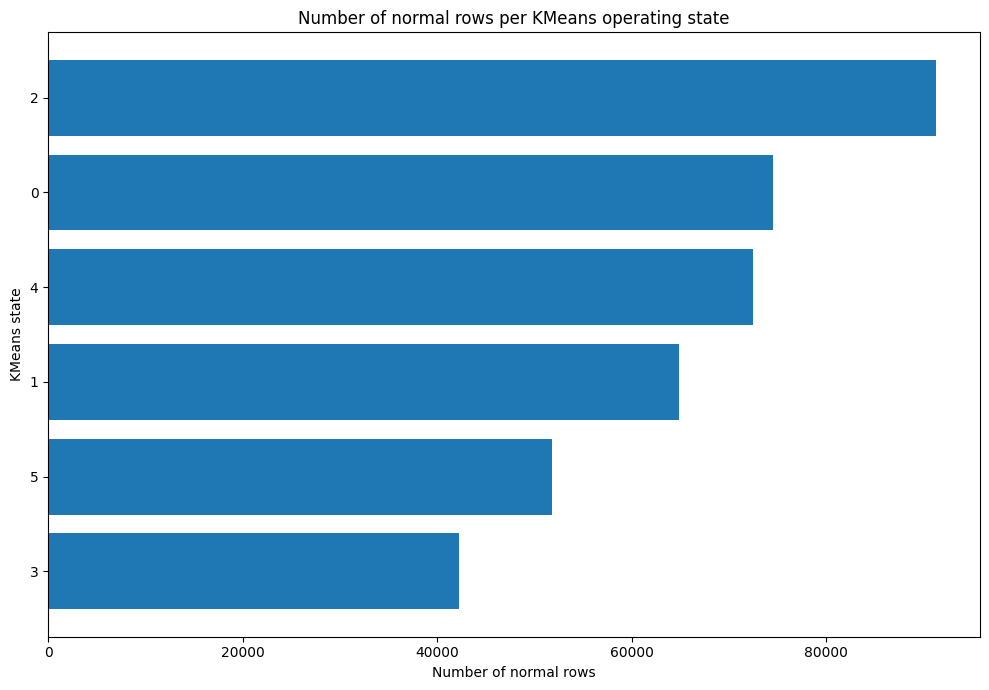

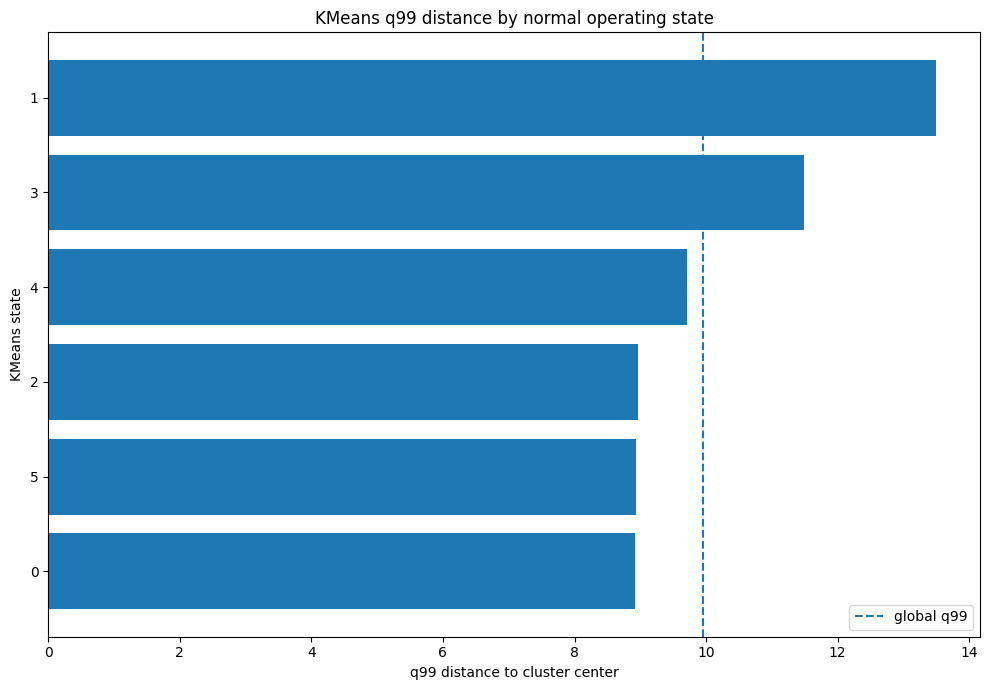

In [ ]:
plot_df = kmeans_summary.sort_values("n", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["kmeans_state"].astype(str), plot_df["n"])
plt.xlabel("Number of normal rows")
plt.ylabel("KMeans state")
plt.title("Number of normal rows per KMeans operating state")
plt.tight_layout()
plt.show()

global_q99 = eda.loc[pos, "kmeans_center_dist"].quantile(0.99)

plot_df = kmeans_summary.sort_values("dist_q99", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["kmeans_state"].astype(str), plot_df["dist_q99"])
plt.axvline(global_q99, linestyle="--", label="global q99")
plt.xlabel("q99 distance to cluster center")
plt.ylabel("KMeans state")
plt.title("KMeans q99 distance by normal operating state")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
try:
    import umap
except ImportError:
    raise ImportError("Please run: !pip install umap-learn")

from sklearn.preprocessing import StandardScaler

UMAP_COLS = MODEL_FEATURE_COLS

PLOT_N = 30000
RANDOM_STATE = 42

rng = np.random.default_rng(RANDOM_STATE)

plot_n = min(PLOT_N, len(pos))
pos_plot = rng.choice(pos, size=plot_n, replace=False)
pos_plot = np.sort(pos_plot)

X = eda.loc[pos_plot, UMAP_COLS].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("UMAP input shape:", X_scaled.shape)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    random_state=RANDOM_STATE
)

X_umap = reducer.fit_transform(X_scaled)

print("UMAP done.")

UMAP input shape: (30000, 49)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done.


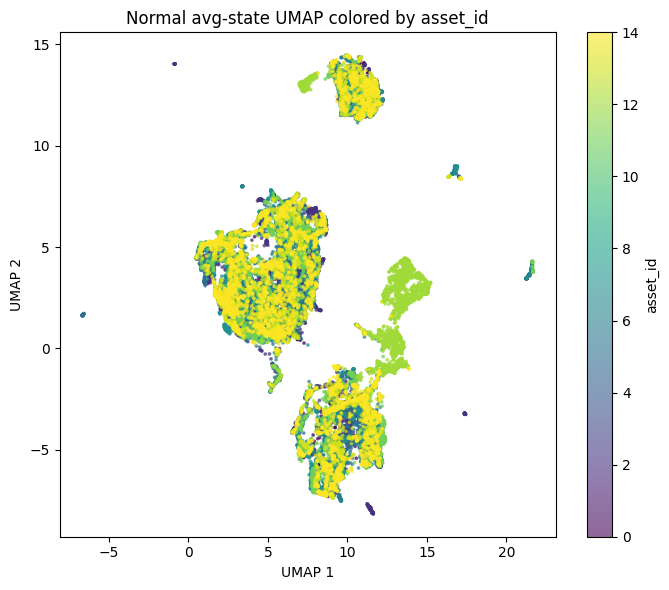

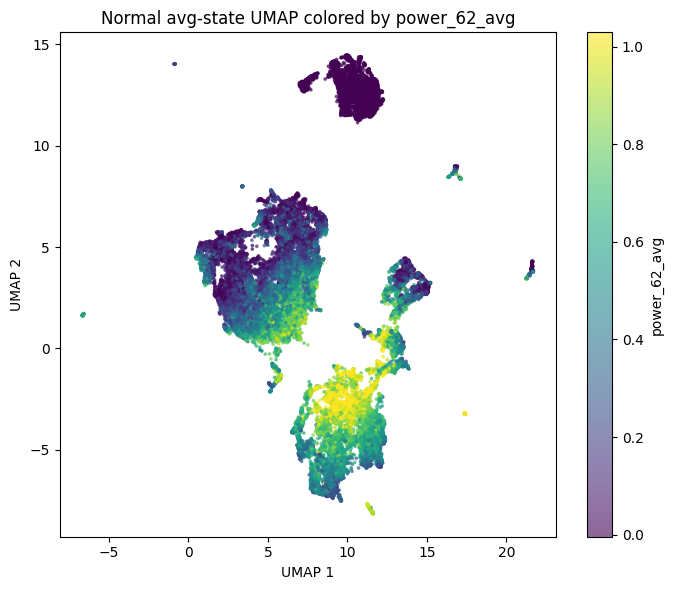

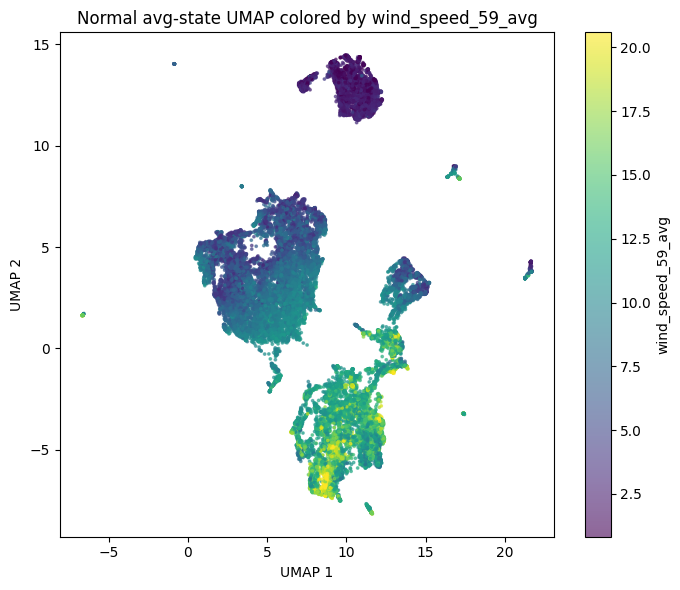

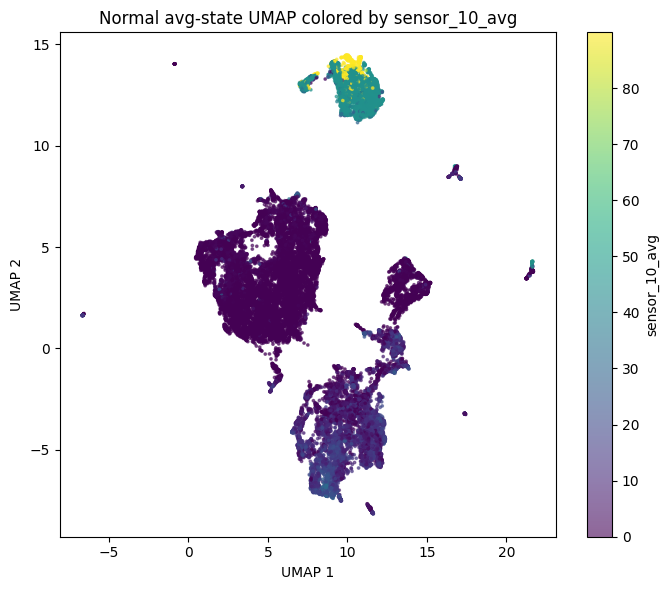

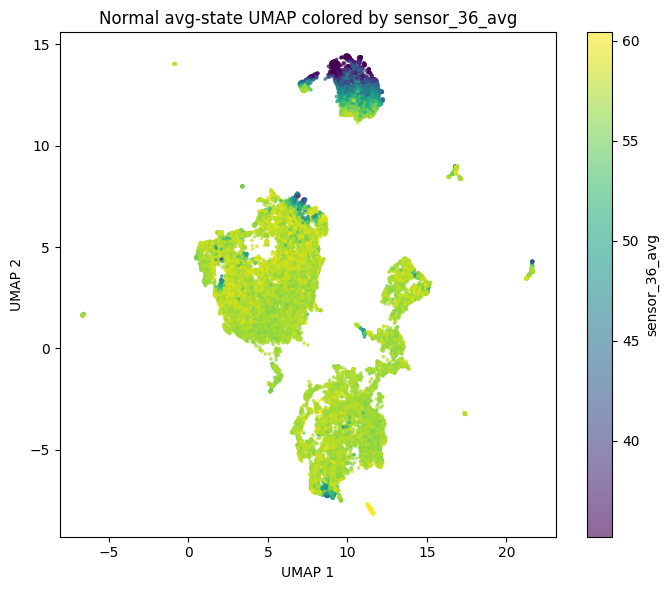

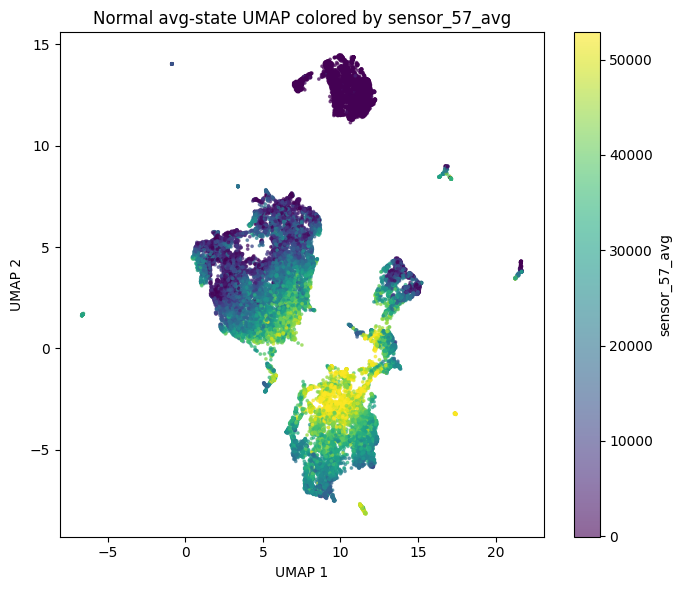

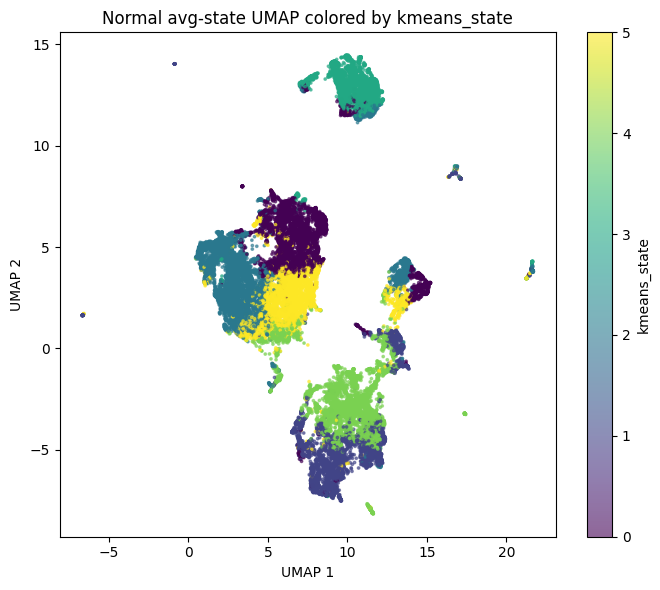

In [ ]:
def plot_umap_by(col, qclip=True):
    if col not in eda.columns:
        print(f"Missing column: {col}")
        return

    values = eda.loc[pos_plot, col]

    plt.figure(figsize=(7, 6))

    if pd.api.types.is_numeric_dtype(values):
        c = values.to_numpy()

        if qclip:
            vmin = np.nanpercentile(c, 1)
            vmax = np.nanpercentile(c, 99)
        else:
            vmin = None
            vmax = None

        sc = plt.scatter(
            X_umap[:, 0],
            X_umap[:, 1],
            c=c,
            s=3,
            alpha=0.6,
            vmin=vmin,
            vmax=vmax
        )
        plt.colorbar(sc, label=col)

    else:
        codes = values.astype("category").cat.codes

        sc = plt.scatter(
            X_umap[:, 0],
            X_umap[:, 1],
            c=codes,
            s=3,
            alpha=0.6
        )
        plt.colorbar(sc, label=col)

    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.title(f"Normal avg-state UMAP colored by {col}")
    plt.tight_layout()
    plt.show()


plot_cols = [
    "asset_id",
    "power_62_avg",
    "wind_speed_59_avg",
    "sensor_10_avg",
    "sensor_36_avg",
    "sensor_57_avg",
    "kmeans_state",
]

for col in plot_cols:
    plot_umap_by(col)

,PC,explained_variance_ratio,cumulative_variance
0,PC1,0.365144,0.365144
1,PC2,0.126920,0.492064
2,PC3,0.121542,0.613606
3,PC4,0.052075,0.665680
4,PC5,0.045420,0.711100
5,PC6,0.035292,0.746392
6,PC7,0.030616,0.777008
7,PC8,0.025033,0.802041
8,PC9,0.023557,0.825598
9,PC10,0.020417,0.846015


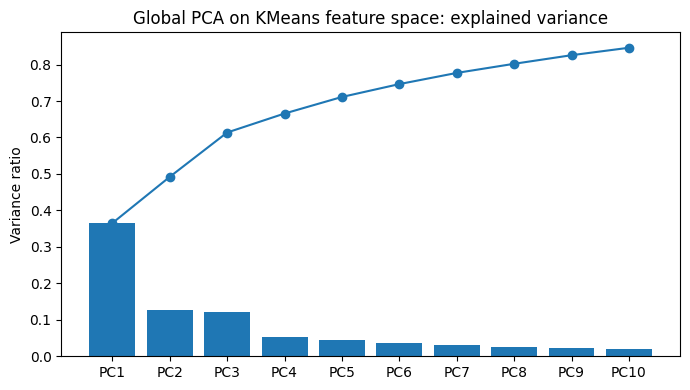

In [ ]:
display(pca_explained)

plt.figure(figsize=(7, 4))
plt.bar(pca_explained["PC"], pca_explained["explained_variance_ratio"])
plt.plot(
    pca_explained["PC"],
    pca_explained["cumulative_variance"],
    marker="o"
)
plt.ylabel("Variance ratio")
plt.title("Global PCA on KMeans feature space: explained variance")
plt.tight_layout()
plt.show()

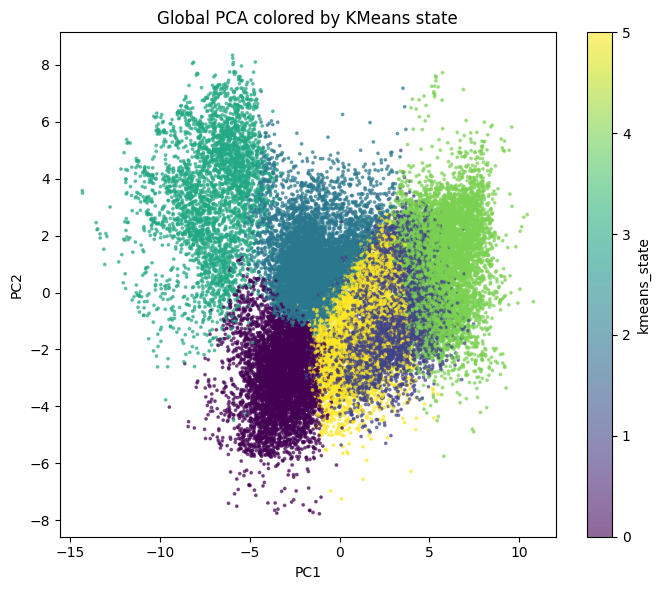

In [ ]:
PLOT_N = 30000
RANDOM_STATE = 42

pc_cols = [c for c in [f"pca_PC{i}" for i in range(1, 11)] if c in eda.columns]

assert "pca_PC1" in eda.columns
assert "pca_PC2" in eda.columns
assert "kmeans_state" in eda.columns

rng = np.random.default_rng(RANDOM_STATE)

plot_n = min(PLOT_N, len(pos))
pos_pca_plot = rng.choice(pos, size=plot_n, replace=False)
pos_pca_plot = np.sort(pos_pca_plot)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    eda.loc[pos_pca_plot, "pca_PC1"],
    eda.loc[pos_pca_plot, "pca_PC2"],
    c=eda.loc[pos_pca_plot, "kmeans_state"],
    s=3,
    alpha=0.6
)
plt.colorbar(sc, label="kmeans_state")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Global PCA colored by KMeans state")
plt.tight_layout()
plt.show()

Family counts in PCA loadings:


,family,n_features
0,transformer_thermal,9
1,ambient_generator_motor_thermal,8
2,gearbox_bearing_oil_thermal,8
3,wind_orientation_pitch_control,7
4,electrical_grid_current_voltage,6
5,power_energy_output,4
6,vibration_structural,4
7,drivetrain_speed_torque,3



Top loading features for PC1:


,feature,family,loading,abs_loading
0,sensor_12_avg,drivetrain_speed_torque,0.216677,0.216677
1,power_62_avg,power_energy_output,0.215334,0.215334
2,sensor_27_avg,electrical_grid_current_voltage,0.215290,0.215290
3,power_58_avg,power_energy_output,0.210078,0.210078
4,sensor_7_avg,power_energy_output,0.204373,0.204373
5,sensor_25_avg,drivetrain_speed_torque,0.198754,0.198754
6,sensor_45_avg,transformer_thermal,0.197789,0.197789
7,wind_speed_61_avg,wind_orientation_pitch_control,0.196603,0.196603
8,sensor_41_avg,transformer_thermal,0.194833,0.194833
9,sensor_23_avg,electrical_grid_current_voltage,0.193489,0.193489


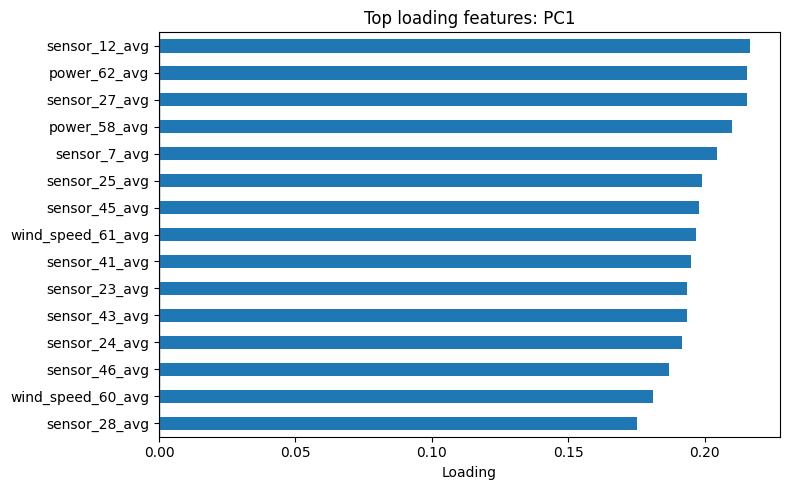


Top loading features for PC2:


,feature,family,loading,abs_loading
0,sensor_53_avg,ambient_generator_motor_thermal,0.361513,0.361513
1,sensor_8_avg,ambient_generator_motor_thermal,0.314614,0.314614
2,sensor_48_avg,ambient_generator_motor_thermal,0.298216,0.298216
3,sensor_49_avg,ambient_generator_motor_thermal,0.296991,0.296991
4,sensor_50_avg,ambient_generator_motor_thermal,0.294620,0.294620
5,sensor_22_avg,ambient_generator_motor_thermal,0.264834,0.264834
6,sensor_31_avg,transformer_thermal,0.242948,0.242948
7,sensor_37_avg,gearbox_bearing_oil_thermal,-0.198735,0.198735
8,sensor_35_avg,gearbox_bearing_oil_thermal,-0.188760,0.188760
9,sensor_39_avg,gearbox_bearing_oil_thermal,-0.187634,0.187634


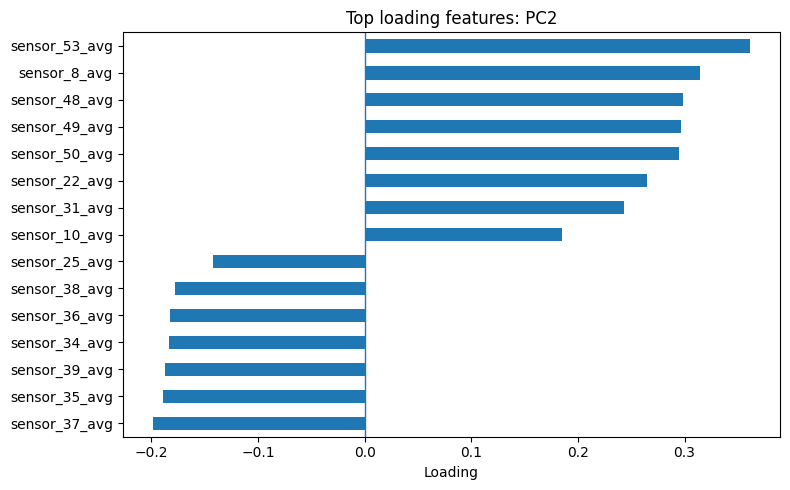


Top loading features for PC3:


,feature,family,loading,abs_loading
0,sensor_38_avg,gearbox_bearing_oil_thermal,0.293811,0.293811
1,sensor_37_avg,gearbox_bearing_oil_thermal,0.287953,0.287953
2,sensor_22_avg,ambient_generator_motor_thermal,0.271156,0.271156
3,sensor_36_avg,gearbox_bearing_oil_thermal,0.260723,0.260723
4,sensor_10_avg,wind_orientation_pitch_control,-0.258158,0.258158
5,sensor_39_avg,gearbox_bearing_oil_thermal,0.254779,0.254779
6,sensor_35_avg,gearbox_bearing_oil_thermal,0.230009,0.230009
7,sensor_31_avg,transformer_thermal,0.209916,0.209916
8,sensor_8_avg,ambient_generator_motor_thermal,0.209036,0.209036
9,sensor_34_avg,gearbox_bearing_oil_thermal,0.208812,0.208812


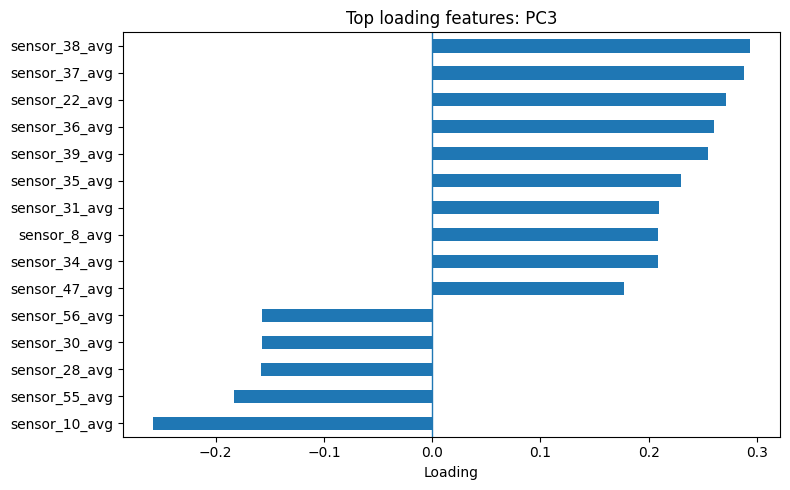


Top loading features for PC4:


,feature,family,loading,abs_loading
0,sensor_29_avg,electrical_grid_current_voltage,0.276502,0.276502
1,sensor_28_avg,electrical_grid_current_voltage,0.262421,0.262421
2,sensor_30_avg,electrical_grid_current_voltage,0.260835,0.260835
3,sensor_49_avg,ambient_generator_motor_thermal,0.250897,0.250897
4,sensor_50_avg,ambient_generator_motor_thermal,0.249681,0.249681
5,sensor_48_avg,ambient_generator_motor_thermal,0.226476,0.226476
6,sensor_42_avg,transformer_thermal,-0.212356,0.212356
7,sensor_44_avg,transformer_thermal,-0.210516,0.210516
8,sensor_46_avg,transformer_thermal,-0.208717,0.208717
9,wind_speed_60_avg,wind_orientation_pitch_control,0.195226,0.195226


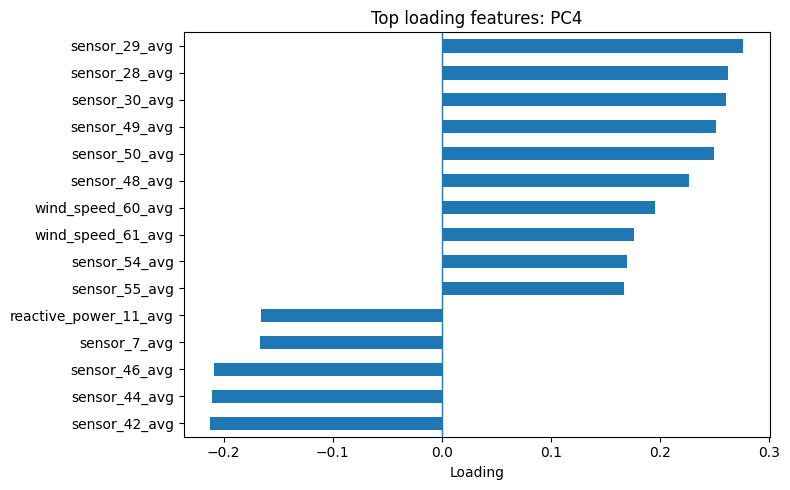


Top loading features for PC5:


,feature,family,loading,abs_loading
0,sensor_21_avg_cos,wind_orientation_pitch_control,0.509200,0.509200
1,sensor_4_avg_cos,wind_orientation_pitch_control,0.507641,0.507641
2,sensor_21_avg_sin,wind_orientation_pitch_control,-0.318684,0.318684
3,sensor_4_avg_sin,wind_orientation_pitch_control,-0.314713,0.314713
4,sensor_55_avg,vibration_structural,0.225370,0.225370
5,sensor_51_avg,gearbox_bearing_oil_thermal,0.197644,0.197644
6,sensor_56_avg,vibration_structural,0.182474,0.182474
7,sensor_52_avg,gearbox_bearing_oil_thermal,0.174321,0.174321
8,sensor_40_avg,transformer_thermal,0.168361,0.168361
9,sensor_33_avg,ambient_generator_motor_thermal,-0.125191,0.125191


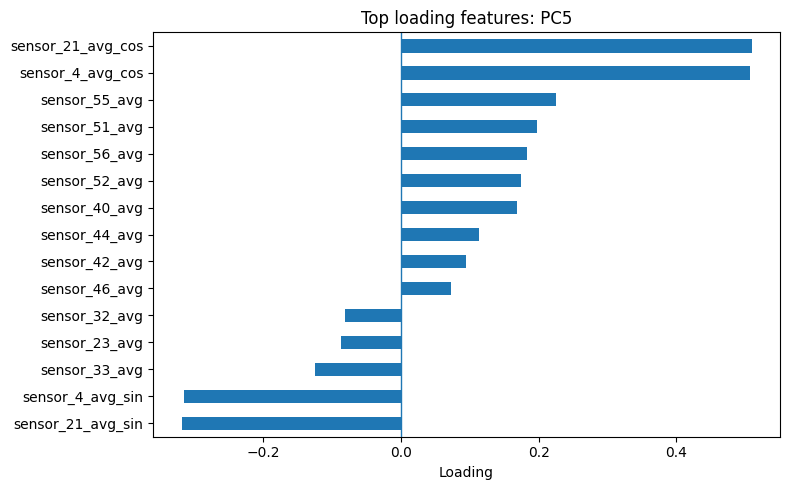

In [ ]:
feature_to_family = {}

for fam, cols in AVG_FAMILY.items():
    for col in cols:
        feature_to_family[col] = fam

feature_family = pd.Series(
    {col: feature_to_family.get(col, "other") for col in pca_loadings.index},
    name="family"
)

print("Family counts in PCA loadings:")
display(feature_family.value_counts().rename_axis("family").reset_index(name="n_features"))

pc_cols = [c for c in pca_loadings.columns if c.startswith("PC")]

for pc in pc_cols[:5]:
    top = (
        pca_loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .head(15)
        .index
    )

    top_table = pd.DataFrame({
        "feature": top,
        "family": feature_family.loc[top].values,
        "loading": pca_loadings.loc[top, pc].values,
        "abs_loading": pca_loadings.loc[top, pc].abs().values
    }).sort_values("abs_loading", ascending=False)

    print(f"\nTop loading features for {pc}:")
    display(top_table)

    plt.figure(figsize=(8, 5))
    pca_loadings.loc[top, pc].sort_values().plot(kind="barh")
    plt.axvline(0, linewidth=1)
    plt.title(f"Top loading features: {pc}")
    plt.xlabel("Loading")
    plt.tight_layout()
    plt.show()

,PC,family,family_loading_sq_sum
0,PC1,transformer_thermal,0.252211
1,PC1,electrical_grid_current_voltage,0.211846
2,PC1,power_energy_output,0.152959
3,PC1,gearbox_bearing_oil_thermal,0.123345
4,PC1,wind_orientation_pitch_control,0.089155
...,...,...,...
75,PC10,gearbox_bearing_oil_thermal,0.020435
76,PC10,ambient_generator_motor_thermal,0.015662
77,PC10,electrical_grid_current_voltage,0.005491
78,PC10,wind_orientation_pitch_control,0.005484


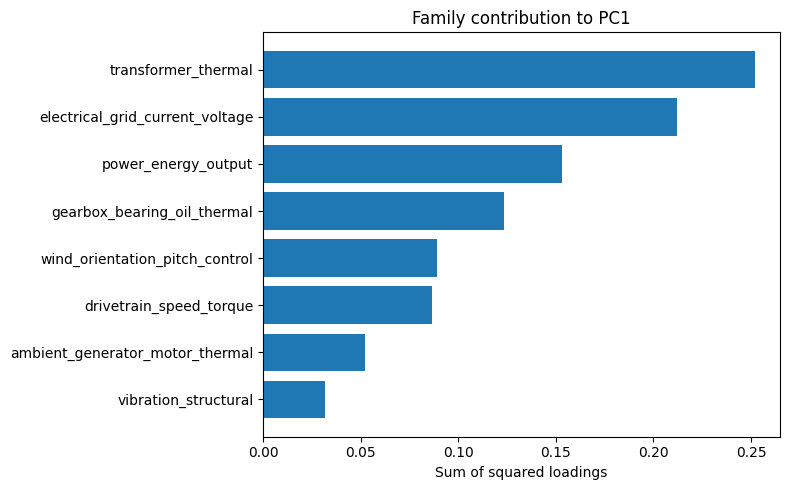

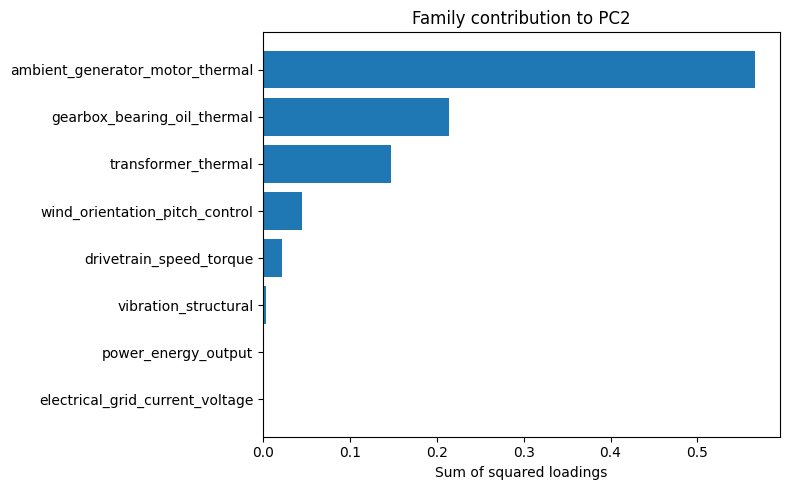

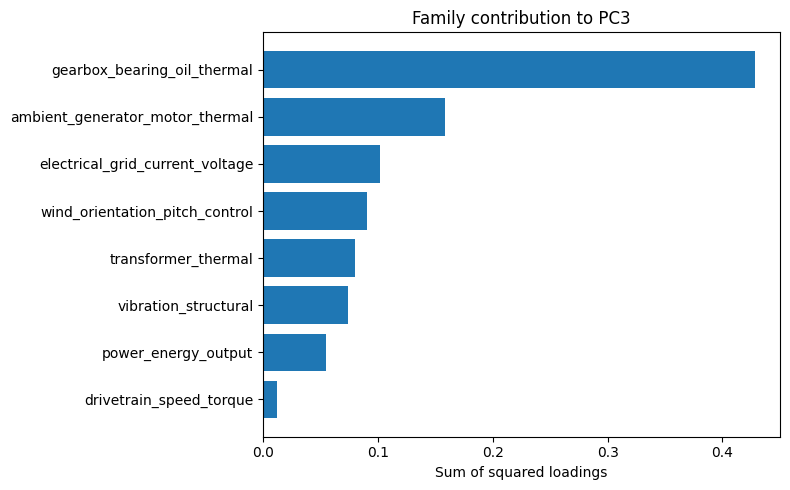

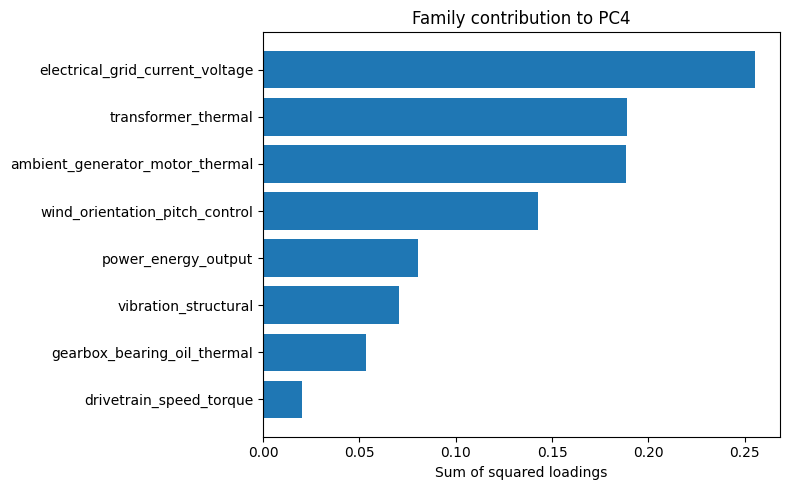

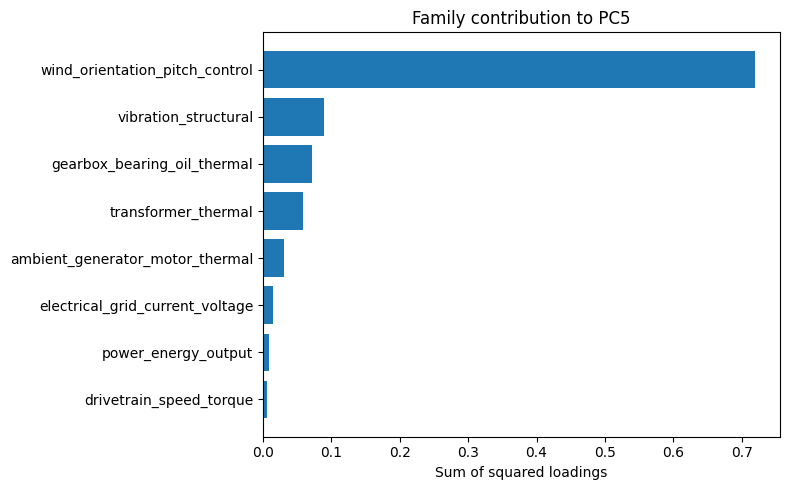

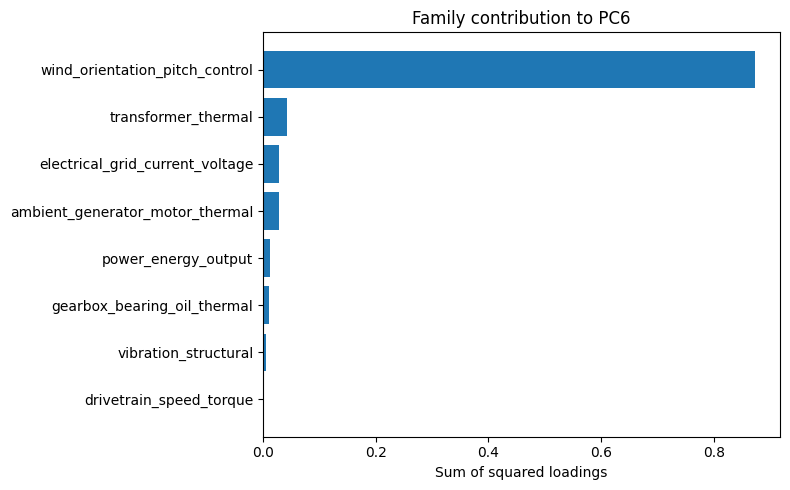

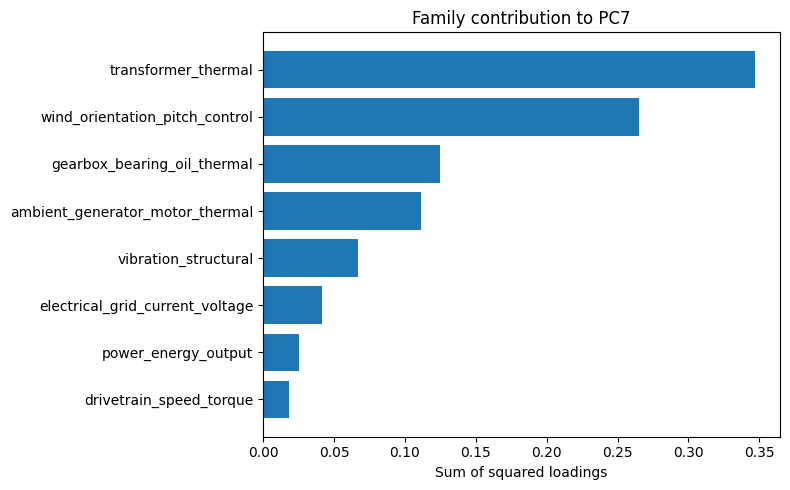

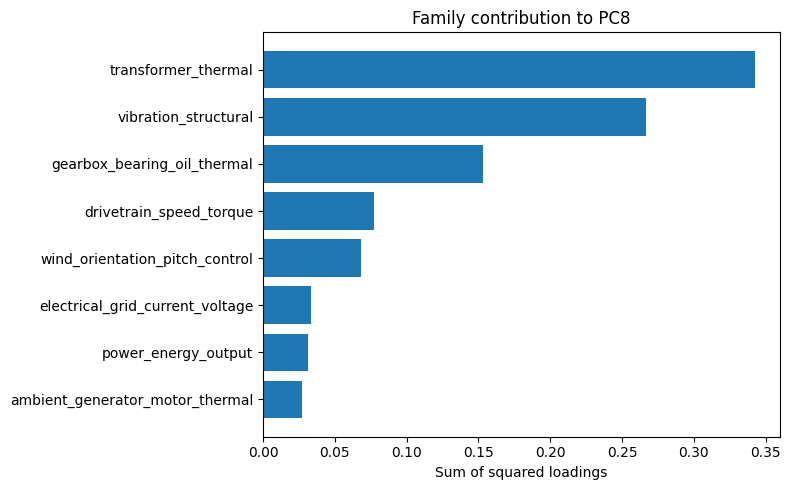

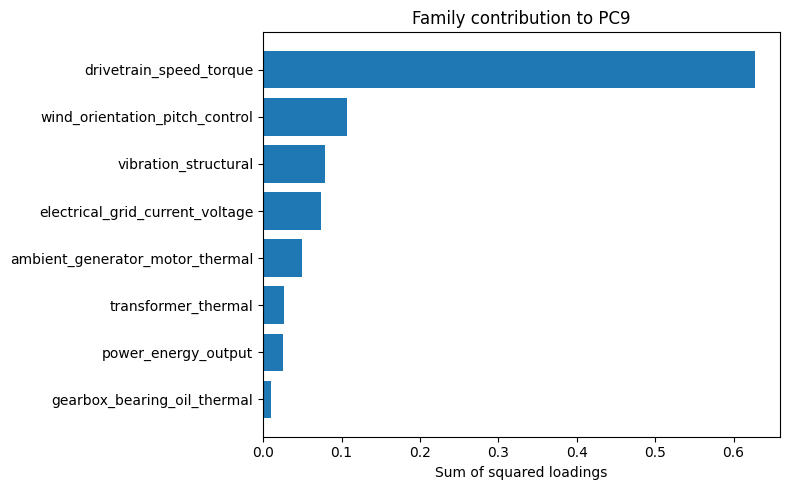

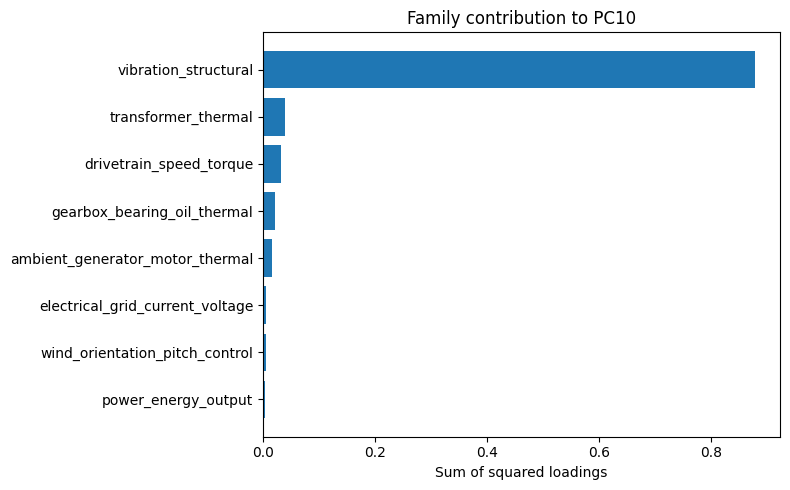

In [ ]:
family_contrib_records = []

for pc in pc_cols:
    tmp = pd.DataFrame({
        "feature": pca_loadings.index,
        "family": feature_family.loc[pca_loadings.index].values,
        "loading_sq": pca_loadings[pc].values ** 2
    })

    fam_sum = (
        tmp.groupby("family")["loading_sq"]
        .sum()
        .sort_values(ascending=False)
    )

    for fam, value in fam_sum.items():
        family_contrib_records.append({
            "PC": pc,
            "family": fam,
            "family_loading_sq_sum": value
        })

pca_family_contrib = pd.DataFrame(family_contrib_records)

display(pca_family_contrib)

for pc in pc_cols[:10]:
    tmp = (
        pca_family_contrib[pca_family_contrib["PC"] == pc]
        .sort_values("family_loading_sq_sum", ascending=True)
    )

    plt.figure(figsize=(8, 5))
    plt.barh(tmp["family"], tmp["family_loading_sq_sum"])
    plt.xlabel("Sum of squared loadings")
    plt.title(f"Family contribution to {pc}")
    plt.tight_layout()
    plt.show()